# __ASSIGNMENT: AI for Sustainability - SRIP 2026__

### __I'm Rikin Pithadia, In this notebook, I am implementing the assignment tasks and try to answer the questions asked in the task. Also I'm going step-by-step for better approach and understanding. Thank yoU!__

In [1]:
# First let's import all the necessary libraries for the project..
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from torchvision.utils import make_grid

%matplotlib inline 

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [2]:
# clearing the caches
torch.cuda.empty_cache()

> __1. Gather the data from the Kaggle Web.__ 

In [6]:
# downloading the data from kaggle
import kagglehub

path = kagglehub.dataset_download("rishabhsnip/earth-observation-delhi-airshed")

print("Path to dataset files:", path)

100%|██████████| 289M/289M [00:19<00:00, 15.2MB/s] 


Extracting files...
Path to dataset files: /home/rikin/.cache/kagglehub/datasets/rishabhsnip/earth-observation-delhi-airshed/versions/1


So the data is downloaded to the working directory.

## __Soultions for the questions...__
# 1. __Spatial Reasoning & Data Filtering [4 Marks]__
    1.  Plot the Delhi-NCR shapefile using matplotlib and overlay a 60×60 km uniform grid (2 marks) 
    2.  Filter satellite images whose center coordinates fall inside the region. (1 mark) 
    3.  Report the total number of images before and after filtering. (1 mark)


Original CRS: EPSG:4326


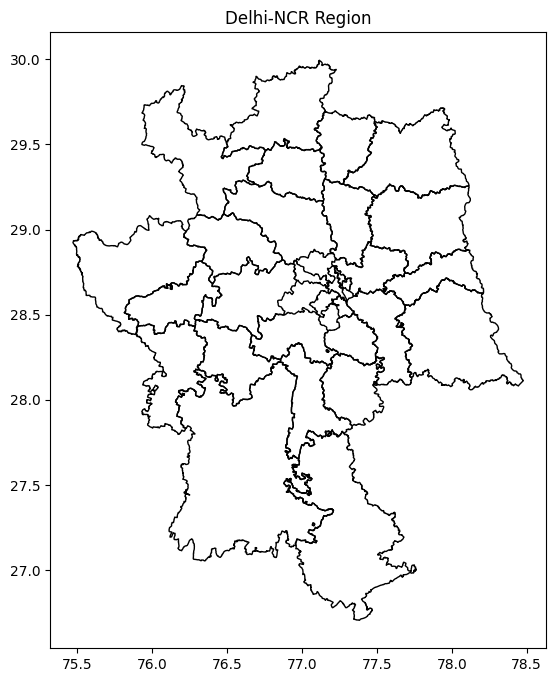

In [3]:
""" Solution 1: Plotting the Delhi-NCR shapefile using matplotlib """

import geopandas as gpd
import matplotlib.pyplot as plt

# loading the geojson file for plotting the Delhi-NCR map
file_path = "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/delhi_ncr_region.geojson"
gdf = gpd.read_file(file_path)

# Check CRS
print("Original CRS:", gdf.crs)

# shapefile
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(ax=ax, edgecolor='black', facecolor='none')
plt.title("Delhi-NCR Region")
plt.show()

In [4]:
# converting to UTM (Meters)
# Delhi lies in UTM Zone 43N (EPSG:32644) (Given)
gdf_utm = gdf.to_crs(epsg=32644)
print("Projected CRS:", gdf_utm.crs)

Projected CRS: EPSG:32644


In [5]:
# Setting the eparameters for grid 

import numpy as np
from shapely.geometry import box

# Grid size in meters
grid_size = 60000   # 60 KM

# Get bounding box
xmin, ymin, xmax, ymax = gdf_utm.total_bounds

# Create grid cells
grid_cells = []

for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))

# Convert to GeoDataFrame
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=gdf_utm.crs)

# Clip grid to Delhi boundary
grid_clipped = gpd.overlay(grid, gdf_utm, how='intersection')

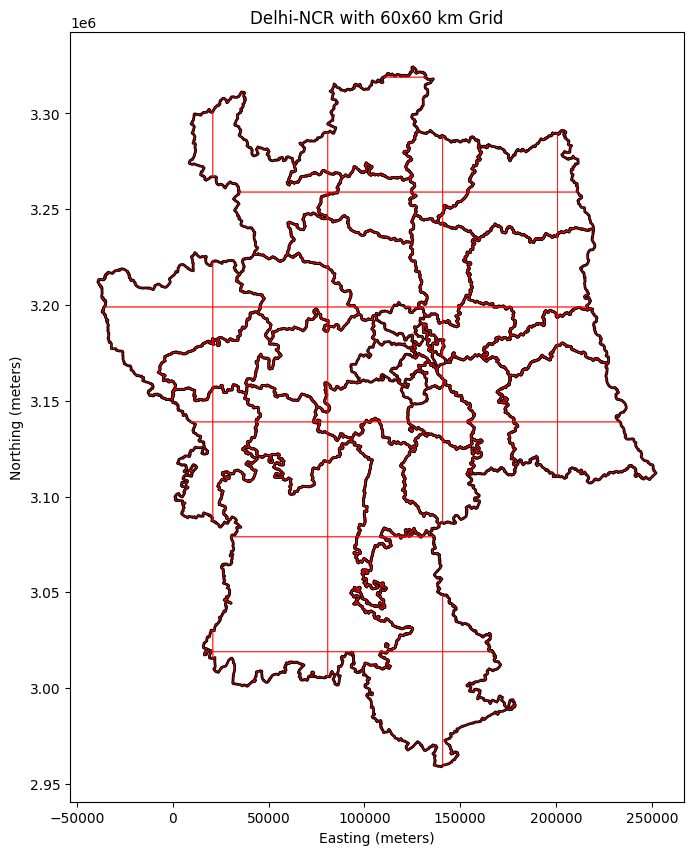

In [6]:
fig, ax = plt.subplots(figsize=(10,10))

# Plot boundary
gdf_utm.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)

# Plot grid
grid_clipped.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=0.5)

plt.title("Delhi-NCR with 60x60 km Grid")
plt.xlabel("Easting (meters)")
plt.ylabel("Northing (meters)")
plt.show()

In [7]:
""" Solution 2: Filter satellite images whose center coordinates fall inside the region."""

# We have the folder called rgb, in which the images with the filename having the coordinates (lat, long). So we have to fetch the coordinates from each of the file.
# Step - by - step process:

# 1. Fetching the original Delhi-NCR boundary EPSG

import geopandas as gpd
region = gpd.read_file("/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/delhi_ncr_region.geojson")
region = region.to_crs("EPSG:4326")

# Getting and extracting the coordinates from all the Image Filenames

import os

image_folder = "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/rgb"
image_files = os.listdir(image_folder)

print("Total Images: ", len(image_files))

Total Images:  9216


In [8]:
# spliiting the file names using '_' for getting the latitude and longitude

from shapely.geometry import Point
import pandas as pd

# coordinates
data = []

for filename in image_files:
    if filename.endswith(".png"):
        name = filename.replace(".png", "")
        lat, lon = name.split("_")

        lat = float(lat)
        lon = float(lon)

        data.append({
            "filename":filename,
            "lat": lat,
            "lon": lon,
            "geometry": Point(lon, lat) 
        })

images_gdf = gpd.GeoDataFrame(data, crs="EPSG:4326")

print("GeoDataFRame Created: ", len(images_gdf))

GeoDataFRame Created:  9216


In [9]:
images_gdf.head(5)

,filename,lat,lon,geometry
0,28.9678_77.4145.png,28.9678,77.4145,POINT (77.4145 28.9678)
1,28.7266_77.2058.png,28.7266,77.2058,POINT (77.2058 28.7266)
2,28.9678_77.3943.png,28.9678,77.3943,POINT (77.3943 28.9678)
3,28.4090_77.0909.png,28.4090,77.0909,POINT (77.0909 28.409)
4,28.6355_76.8734.png,28.6355,76.8734,POINT (76.8734 28.6355)


In [10]:
## Filtering the images with the coordinates

region_union = region.union_all()

filtered_images = images_gdf[images_gdf.within(region_union)]

print("Images that falls in Delhi-NCR Region: ", len(filtered_images))

Images that falls in Delhi-NCR Region:  8015


> __Therefore according to the spatial coordinates the total number of satellite images that are in the DelhiNCR region are 8015.__

In [11]:
""" Solution 3: Report the total number of images before and after filtering."""


print("************* Report of Image Filteration Before and After Scenarios **************")
print("Total Images Before Filtering: ", len(image_files))
print("Images After Filtering: ", len(filtered_images))

************* Report of Image Filteration Before and After Scenarios **************
Total Images Before Filtering:  9216
Images After Filtering:  8015


> So, here i Conclude my 1st Solution..

# 2. __Label Construction & Dataset Preparation [6  Marks]__
    1. For  each  image,  extract  the   128×128  corresponding  land-cover  patch  from land_cover.tif using its center coordinate (2 marks) 
    2. Assign the image label using the dominant (mode) land-cover class. (1 mark) 
    3. Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others). (1 mark) 
    4. Perform a 60/40 train-test split randomly and visualize class distribution (2 mark)

Opening: /home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/worldcover_bbox_delhi_ncr_2021.tif
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 9602, 'height': 9600, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.333333333333333e-05, 0.0, 76.84991666666667,
       0.0, -8.333333333333333e-05, 29.0), 'blockxsize': 9602, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}


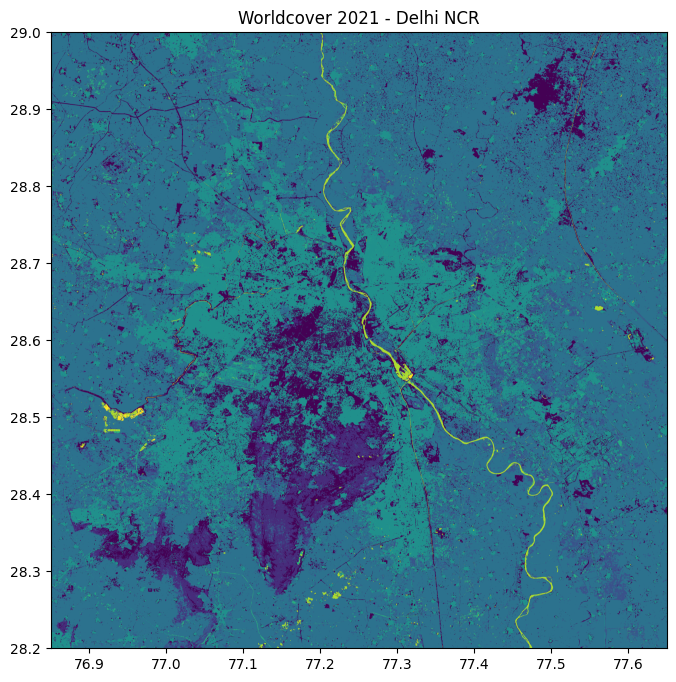

In [ ]:
# Previewing the TIFF/GeoPackage data
import rasterio
from rasterio.plot import show

# path to the worldcover TIFF

base_tif = "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/worldcover_bbox_delhi_ncr_2021.tif"

print("Opening:", base_tif)
with rasterio.open(base_tif) as src:
    print(src.profile)
    fig, ax = plt.subplots(figsize=(8, 8))
    show(src, ax=ax, cmap="viridis")
    ax.set_title("Worldcover 2021 - Delhi NCR")
    plt.show()

In [ ]:
""" Solution 1. For  each  image,  extract  the   128×128  corresponding  land-cover  patch  from land_cover.tif using its center coordinate """
# Converting Cooordinate into Pixel
# geting the raster file using rasterio lib

import rasterio

landcover_path = "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/worldcover_bbox_delhi_ncr_2021.tif"
src = rasterio.open(landcover_path)

print("Raster CRS: ", src.crs)
print("Raster Shape: ", src.width, "," , src.height)

Raster CRS:  EPSG:4326
Raster Shape:  9602 , 9600


In [ ]:
from pyproj import Transformer

transformer = Transformer.from_crs(
    "EPSG:4326", 
    src.crs,
    always_xy=True
)

In [ ]:
# image coordinate --> Pixel

# Test case....
filename = "28.2056_76.8646.png"  

lat, lon = filename.replace(".png", "").split("_")
lat, lon = float(lat), float(lon)

# raster crs
x, y = transformer.transform(lon, lat)

row, col = src.index(x, y)

print("Pixel Location: ", row, "," , col)

Pixel Location:  9532 , 176


In [22]:
# Window of 128 x 128

from rasterio.windows import Window

patch_size = 128
half = patch_size // 2

window = Window(
    col - half,
    row - half,
    patch_size,
    patch_size
)

patch = src.read(1, window=window) 
print(patch.shape)

(128, 128)


In [23]:
# Applying this transformation and Window in all the images

# saving the patches in a dictionary format
patches = {}

for filename in image_files:
    if filename.endswith(".png"):
        try:
            lat, lon = filename.replace(".png", "").split("_")
            lat, lon = float(lat), float(lon)

            # convert to ratser crs
            x, y = transformer.transform(lon, lat)

            # convert to pixel
            row, col = src.index(x, y)

            # window 
            window = Window(
                col - half,
                row - half,
                patch_size,
                patch_size
            )

            patch = src.read(1, window=window)

            # Skip,  if patch is incomplete (near borders)
            if patch.shape == (128, 128):
                patches[filename] = patch
            
        except Exception as e:
            continue

print("Total patches: ", len(patches))

Total patches:  9216


In [27]:
patches

{'28.9678_77.4145.png': array([[50, 50, 50, ..., 40, 40, 40],
        [50, 50, 50, ..., 40, 40, 40],
        [50, 50, 50, ..., 40, 40, 40],
        ...,
        [40, 40, 40, ..., 40, 40, 40],
        [40, 40, 40, ..., 40, 40, 10],
        [40, 40, 40, ..., 40, 40, 10]], shape=(128, 128), dtype=uint8),
 '28.7266_77.2058.png': array([[60, 30, 30, ..., 50, 50, 50],
        [60, 30, 30, ..., 50, 50, 50],
        [60, 50, 30, ..., 50, 50, 50],
        ...,
        [50, 50, 50, ..., 10, 10, 10],
        [50, 50, 50, ..., 10, 10, 10],
        [50, 50, 50, ..., 10, 10, 10]], shape=(128, 128), dtype=uint8),
 '28.9678_77.3943.png': array([[50, 50, 50, ..., 40, 40, 10],
        [50, 50, 50, ..., 40, 10, 10],
        [50, 50, 50, ..., 40, 40, 40],
        ...,
        [40, 40, 40, ..., 40, 40, 40],
        [40, 40, 40, ..., 40, 40, 40],
        [40, 40, 40, ..., 40, 40, 40]], shape=(128, 128), dtype=uint8),
 '28.4090_77.0909.png': array([[50, 50, 50, ..., 50, 50, 50],
        [50, 50, 50, ..., 50,

> __So now our image are in a pixel form or a Numpy array with Pixel values as patch.__

In [36]:
""" Solution 2: Assign the image label using the dominant (mode) land-cover class."""

# defining a function for getting the dominant class

import numpy as np

def get_dominant_class(patch, nodata_values=[0, 255]):
    
    flat = patch.flatten()
    
    # remove nodata values
    for nd in nodata_values:
        flat = flat[flat != nd]
    
    if len(flat) == 0:
        return None   # skip image
    
    values, counts = np.unique(flat, return_counts=True)
    return values[np.argmax(counts)]


In [41]:
# lablelling the Images

image_labels = {}

for fname, patch in patches.items():
    label = get_dominant_class(patch)

    if label is not None:
        image_labels[fname] = label

print("Total labeled Images: ", len(image_labels))

Total labeled Images:  9216


In [43]:
image_labels

{'28.9678_77.4145.png': np.uint8(40),
 '28.7266_77.2058.png': np.uint8(50),
 '28.9678_77.3943.png': np.uint8(40),
 '28.4090_77.0909.png': np.uint8(50),
 '28.6355_76.8734.png': np.uint8(40),
 '28.8556_76.9822.png': np.uint8(40),
 '28.3266_77.1645.png': np.uint8(20),
 '28.4090_77.2558.png': np.uint8(20),
 '28.6443_77.5410.png': np.uint8(40),
 '28.2056_77.5821.png': np.uint8(40),
 '28.5057_77.4944.png': np.uint8(50),
 '28.3354_77.5410.png': np.uint8(30),
 '28.5355_76.8646.png': np.uint8(40),
 '28.5267_77.0557.png': np.uint8(10),
 '28.8178_77.0821.png': np.uint8(60),
 '28.5443_76.8822.png': np.uint8(40),
 '28.8679_76.9409.png': np.uint8(40),
 '28.7090_77.2322.png': np.uint8(10),
 '28.7354_77.0909.png': np.uint8(50),
 '28.9766_76.9409.png': np.uint8(40),
 '28.9678_77.5645.png': np.uint8(40),
 '28.9942_76.9321.png': np.uint8(40),
 '28.6179_77.4233.png': np.uint8(50),
 '28.6056_77.6146.png': np.uint8(10),
 '28.6091_77.5058.png': np.uint8(40),
 '28.8556_77.1909.png': np.uint8(40),
 '28.6179_77

> __Labels are assigned to total of 9216 Images based on Mode of the Data..__

In [62]:
""" Solution 3: Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others) """

# pyhton dictionary for mapping the classes to ESA class codes

# offical esa classes
esa_to_simplified = {
    50: "Built-up",
    40: "Cropland",
    80: "Water",
    10: "Vegetation",
    20: "Vegetation",
    30: "Vegetation",
    90: "Vegetation",
    95: "Vegetation",
    100: "Vegetation",
    60: "Others",
    70: "Others"
}

# Simple map
simplified_mapping = {
    "Built-up": "Built-up",
    "Cropland": "Cropland",
    "Water": "Water",
    
    "Tree cover": "Vegetation",
    "Shrubland": "Vegetation",
    "Grassland": "Vegetation",
    "Wetland": "Vegetation",
    "Mangroves": "Vegetation",
    "Moss & lichen": "Vegetation",
    
    "Bare / sparse vegetation": "Others",
    "Snow & ice": "Others"
}

# for training the model
category_to_index = {
    "Built-up": 0,
    "Vegetation": 1,
    "Water": 2,
    "Cropland": 3,
    "Others": 4
}

In [ ]:
# Function for labelling the images

def assign_label_from_patch(patch, nodata_values=[0, 255]):
    
    flat = patch.flatten()
    
    # Remove nodata
    for nd in nodata_values:
        flat = flat[flat != nd]
    
    if len(flat) == 0:
        return None
    
    # dominant ESA code
    values, counts = np.unique(flat, return_counts=True)
    dominant_esa = values[np.argmax(counts)]
    
    # ESA name
    esa_name = esa_to_simplified.get(dominant_esa, "Unknown")
    
    # Simplified category
    simplified_mapping = {
        "Built-up": "Built-up",
        "Cropland": "Cropland",
        "Water": "Water",

        "Tree cover": "Vegetation",
        "Shrubland": "Vegetation",
        "Grassland": "Vegetation",
        "Wetland": "Vegetation",
        "Mangroves": "Vegetation",
        "Moss & lichen": "Vegetation",
        
        "Bare / sparse vegetation": "Others",
        "Snow & ice": "Others"
    }
    
    final_category = simplified_mapping.get(esa_name, "Others")
     
    # Numeric label for model
    category_to_index = {
        "Built-up": 0,
        "Vegetation": 1,
        "Water": 2,
        "Cropland": 3,
        "Others": 4
    }
    
    return category_to_index[final_category]

In [59]:
# Label the images
for filename in image_files:
    
    if not filename.endswith(".png"):
        continue
    
    try:
        # Extract lat/lon
        lat, lon = filename.replace(".png", "").split("_")
        lat, lon = float(lat), float(lon)
        
        # Convert to raster CRS
        x, y = transformer.transform(lon, lat)
        
        # Convert to pixel location
        row, col = src.index(x, y)
        
        # Extract 128x128 patch
        window = Window(
            col - half,
            row - half,
            patch_size,
            patch_size
        )
        
        patch = src.read(1, window=window)
        
        # Skip incomplete patches (near edges)
        if patch.shape != (128, 128):
            continue
        
        # Assign label
        label = assign_label_from_patch(patch)
        
        if label is not None:
            image_labels[filename] = label
    
    except Exception:
        continue

print("Total labeled images:", len(image_labels))

Total labeled images: 9216


In [64]:
converted_labels = {}

for fname, esa_code in image_labels.items():
    
    esa_code = int(esa_code)  # convert np.uint8 → int
    
    simplified = esa_to_simplified.get(esa_code, "Others")
    
    final_label = category_to_index[simplified]
    
    converted_labels[fname] = final_label

In [65]:
converted_labels

{'28.9678_77.4145.png': 3,
 '28.7266_77.2058.png': 0,
 '28.9678_77.3943.png': 3,
 '28.4090_77.0909.png': 0,
 '28.6355_76.8734.png': 3,
 '28.8556_76.9822.png': 3,
 '28.3266_77.1645.png': 1,
 '28.4090_77.2558.png': 1,
 '28.6443_77.5410.png': 3,
 '28.2056_77.5821.png': 3,
 '28.5057_77.4944.png': 0,
 '28.3354_77.5410.png': 1,
 '28.5355_76.8646.png': 3,
 '28.5267_77.0557.png': 1,
 '28.8178_77.0821.png': 4,
 '28.5443_76.8822.png': 3,
 '28.8679_76.9409.png': 3,
 '28.7090_77.2322.png': 1,
 '28.7354_77.0909.png': 0,
 '28.9766_76.9409.png': 3,
 '28.9678_77.5645.png': 3,
 '28.9942_76.9321.png': 3,
 '28.6179_77.4233.png': 0,
 '28.6056_77.6146.png': 1,
 '28.6091_77.5058.png': 3,
 '28.8556_77.1909.png': 3,
 '28.6179_77.1410.png': 0,
 '28.7767_76.9321.png': 3,
 '28.2354_77.3734.png': 3,
 '28.6179_77.6146.png': 3,
 '28.9178_77.3943.png': 3,
 '28.3679_77.0645.png': 0,
 '28.2056_77.5909.png': 3,
 '28.6355_77.4409.png': 0,
 '28.8090_77.2943.png': 3,
 '28.2090_76.9145.png': 3,
 '28.2591_77.2646.png': 3,
 

In [66]:
image_labels = converted_labels

In [67]:
image_labels["28.2056_76.9145.png"]

3

In [68]:
from collections import Counter

label_counts = Counter(image_labels.values())

print(label_counts)

Counter({3: 6011, 0: 2260, 1: 935, 2: 7, 4: 3})


> __So now the data has labeled form, and can be use for training the model...__

In [70]:
""" Solution 4: Perform a 60/40 train-test split randomly and visualize class distribution"""

import pandas as pd

df = pd.DataFrame({
    "filename": list(image_labels.keys()),
    "label": list(image_labels.values())
})

print(df.head())
print("Total samples:", len(df))

              filename  label
0  28.9678_77.4145.png      3
1  28.7266_77.2058.png      0
2  28.9678_77.3943.png      3
3  28.4090_77.0909.png      0
4  28.6355_76.8734.png      3
Total samples: 9216


In [72]:
# i use sklearn for spliiting the data into training and testing
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, 
                                     test_size=0.4, 
                                     random_state=29, 
                                     stratify=df["label"] # For balancing
                                     )

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 5529
Test size: 3687


In [ ]:
# Plotting the distribution for Full, Train and Test Data.
category_to_index = {
        "Built-up": 0,
        "Vegetation": 1,
        "Water": 2,
        "Cropland": 3,
        "Others": 4
    }

# function for plotting the distribution
def distribution_plot(dataframe, title):

    counts = dataframe['label'].value_counts().sort_index()

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel("class Label")
    plt.ylabel("Samples")
    plt.show

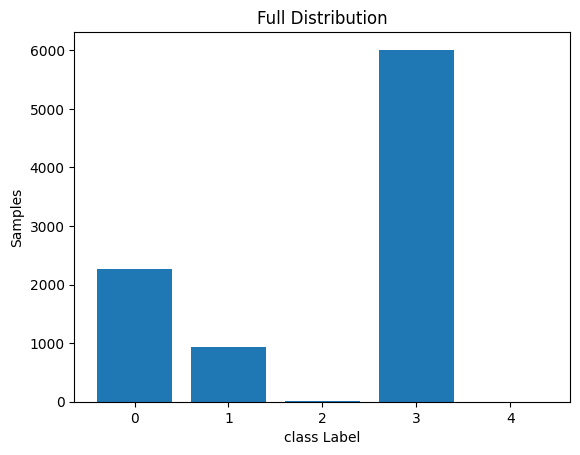

In [76]:
# Full data plot
distribution_plot(df, "Full Distribution")

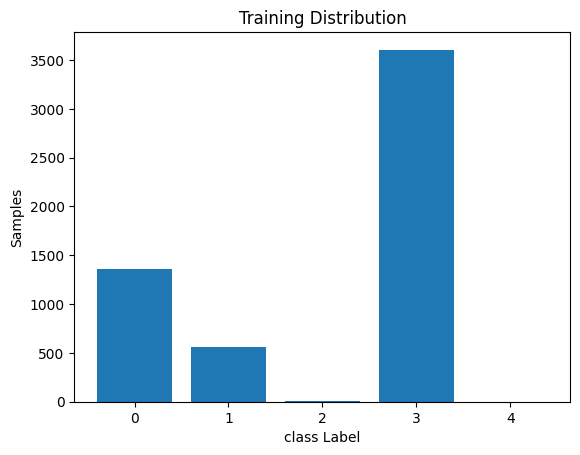

In [77]:
# Training Data Distribution
distribution_plot(train_df, "Training Distribution")

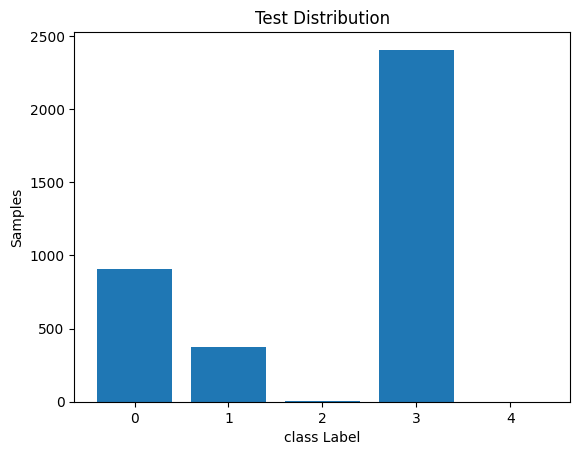

In [79]:
# Testing Data Distribution
distribution_plot(test_df, "Test Distribution")

### __*So here is the Distributions of the Data for Training and Test. It's similar for both, so there is less chances of error of Model to prediction in test data after training.*__

# 3. __Model Training & Supervised Evaluation [5 Marks]__
    1. Train a CNN model (e.g., ResNet18 or a simple custom CNN) for land-use classification. (2 marks) 
    2. Evaluate using accuracy and F1-score. (2 marks) 
    3. Display a confusion matrix and briefly interpret the results. (1 mark) 


In [81]:
""" Solution 1. Train a CNN Model """

# Here I am using ResNet18 model, because I have prior experience and familiarity of training a ResNet9 Model earlier in my projects...

# I am staring with dataset and dataloader for PyTorch for training the model.
train_df.to_csv("train_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [ ]:
# Getting the splitts
train_df = pd.read_csv("train_split.csv")
test_df = pd.read_csv("test_split.csv")

In [21]:
# Dataset class for implementing Dataloader for PyTorch
import os
from PIL import Image
from torch.utils.data import Dataset

class LandUseDataset(Dataset):
    
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["filename"])
        
        image = Image.open(img_path).convert("RGB")
        label = row["label"]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [22]:
# transforms for training the ResNet18 model
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [23]:
# Datasets
train_dataset = LandUseDataset(train_df, "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/rgb", transform=train_transforms)
test_dataset = LandUseDataset(test_df, "/home/rikin/srip-assignment-2026/earth-observation-delhi-airshed/versions/1/rgb", transform=test_transforms)

In [24]:
# DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
# moving the dataloader to GPU for smooth training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [34]:
from collections import Counter
import torch
import torch.nn as nn

train_counts = Counter(train_df["label"])
print(train_counts)

Counter({3: 3606, 0: 1356, 1: 561, 2: 4, 4: 2})


In [35]:
class_counts = torch.tensor([
    train_counts[0],
    train_counts[1],
    train_counts[2],
    train_counts[3],
    train_counts[4]
], dtype=torch.float)

print(class_counts)

tensor([1.3560e+03, 5.6100e+02, 4.0000e+00, 3.6060e+03, 2.0000e+00])


In [ ]:
weights = 1.0 / class_counts
weights = weights / weights.sum()   # normalize

print(weights)

tensor([9.7963e-04, 2.3679e-03, 3.3209e-01, 3.6838e-04, 6.6419e-01])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# definingthe weighted CrossEntropyLoss for the model evaluation
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

In [ ]:
import torch.nn.functional as F

# Accuracy
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


# Base Class for model
class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch, criterion=criterion):
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        
        out = self(images)
        loss = criterion(out, labels)
        return loss
    
    def evaluation_step(self, batch, criterion=criterion):
        images, labels = batch
        images, labels = images.to(device), labels.to(device)
        
        out = self(images)
        loss = criterion(out, labels)
        acc = accuracy(out, labels)
        return {'loss': loss.detach(), 'acc': acc}
    
    def evaluation_epoch_end(self, outputs):
        batch_losses = [x['loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        
        batch_accs = [x['acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        
        return {'loss': epoch_loss.item(), 'acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch}] | "
              f"LR: {result['lrs'][-1]:.5f} | "
              f"Train Loss: {result['train_loss']:.4f} | "
              f"Test Loss: {result['test_loss']:.4f} | "
              f"Test Acc: {result['test_acc']:.4f}")

In [ ]:
## ResNet18 Core 
import torch
import torch.nn as nn
import torch.nn.functional as F


# Basic core block to be used in ResNet model
class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Identity / projection shortcut
        self.shortcut = nn.Sequential()
        
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [ ]:
# Main Model 
class ResNet18(ImageClassificationBase):
    
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        self.in_channels = 64
        
        # Initial conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # Residual Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def _make_layer(self, out_channels, blocks, stride):
        
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, xb):
        out = self.conv1(xb)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.classifier(out)
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet18(in_channels=3, num_classes=5)
model = model.to(device) # transfering model to GPU..

In [43]:
model

ResNet18(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): 

In [ ]:
# Learning rate
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

# Fit one cycle approach for stable taining, and Adam Optimizer
def fit_one_cycle(epochs, max_lr, model, train_loader, test_loader, 
                  criterion, weight_decay=0, grad_clip=None, 
                  opt_func=torch.optim.Adam):
    
    torch.cuda.empty_cache()
    history = []
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr, epochs=epochs,
        steps_per_epoch=len(train_loader)
    )
    
    for epoch in range(epochs):
        
        # Training
        model.train()
        train_losses = []
        lrs = []
        
        for batch in train_loader:
            
            loss = model.training_step(batch, criterion)
            train_losses.append(loss)
            
            loss.backward()
            
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
            
            optimizer.step()
            optimizer.zero_grad()
            
            lrs.append(get_lr(optimizer))
            sched.step()
        
        # Testing Phase
        model.eval()
        outputs = []
        
        with torch.no_grad():
            for batch in test_loader:
                outputs.append(model.evaluation_step(batch, criterion))
        
        result = model.evaluation_epoch_end(outputs)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        result['test_loss'] = result['loss']
        result['test_acc'] = result['acc']
        
        model.epoch_end(epoch, result)
        history.append(result)
    
    return history

In [ ]:
# Training the model for 15 epochs
history = fit_one_cycle(
    epochs=15,
    max_lr=1e-3,
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    weight_decay=1e-4,
    grad_clip=0.1
)

Epoch [0] | LR: 0.00015 | Train Loss: 0.9255 | Test Loss: 1.1225 | Test Acc: 0.7469
Epoch [1] | LR: 0.00044 | Train Loss: 0.8365 | Test Loss: 0.8817 | Test Acc: 0.6533
Epoch [2] | LR: 0.00076 | Train Loss: 0.8330 | Test Loss: 0.9628 | Test Acc: 0.6880
Epoch [3] | LR: 0.00097 | Train Loss: 0.8897 | Test Loss: 1.2531 | Test Acc: 0.7760
Epoch [4] | LR: 0.00099 | Train Loss: 0.8981 | Test Loss: 1.1692 | Test Acc: 0.6117
Epoch [5] | LR: 0.00095 | Train Loss: 0.7906 | Test Loss: 0.7732 | Test Acc: 0.7928
Epoch [6] | LR: 0.00087 | Train Loss: 0.7904 | Test Loss: 0.8208 | Test Acc: 0.7420
Epoch [7] | LR: 0.00075 | Train Loss: 0.7781 | Test Loss: 0.7939 | Test Acc: 0.7460
Epoch [8] | LR: 0.00061 | Train Loss: 0.7135 | Test Loss: 0.7001 | Test Acc: 0.8605
Epoch [9] | LR: 0.00046 | Train Loss: 0.6936 | Test Loss: 0.7991 | Test Acc: 0.7903
Epoch [10] | LR: 0.00032 | Train Loss: 0.6635 | Test Loss: 0.6030 | Test Acc: 0.7953
Epoch [11] | LR: 0.00019 | Train Loss: 0.6324 | Test Loss: 0.5808 | Test Ac

In [ ]:
""" Solution 2: Evaluate using accuracy and F1-score."""
import torch
from sklearn.metrics import accuracy_score, f1_score

# Getting the model results for Test Data
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        

In [ ]:
# Accuracy on Test data
accuracy = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", round(accuracy, 4))

Test Accuracy: 0.8544


In [ ]:
# Macro F1 for extreme class imbalance
f1_macro = f1_score(all_labels, all_preds, average='macro')
print("F1 Score (Macro):", round(f1_macro, 4))

F1 Score (Macro): 0.4694


In [ ]:
# weighted F1 score 
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print("F1 Score (Weighted):", round(f1_weighted, 4))

F1 Score (Weighted): 0.8657


##  __*The accuracy for Test Data is 85.44 % and Weighted F1-Score is 0.8657..*__ 

In [ ]:
from sklearn.metrics import classification_report

# Confusion matrix for all the classes
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       904
           1       0.45      0.77      0.57       374
           2       0.00      0.00      0.00         3
           3       0.96      0.87      0.91      2405
           4       0.00      0.00      0.00         1

    accuracy                           0.85      3687
   macro avg       0.46      0.50      0.47      3687
weighted avg       0.89      0.85      0.87      3687



/home/rikin/srip-assignment-2026/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rikin/srip-assignment-2026/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rikin/srip-assignment-2026/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [54]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[ 763  102    0   39    0]
 [  39  288    0   47    0]
 [   0    3    0    0    0]
 [  65  241    0 2099    0]
 [   1    0    0    0    0]]


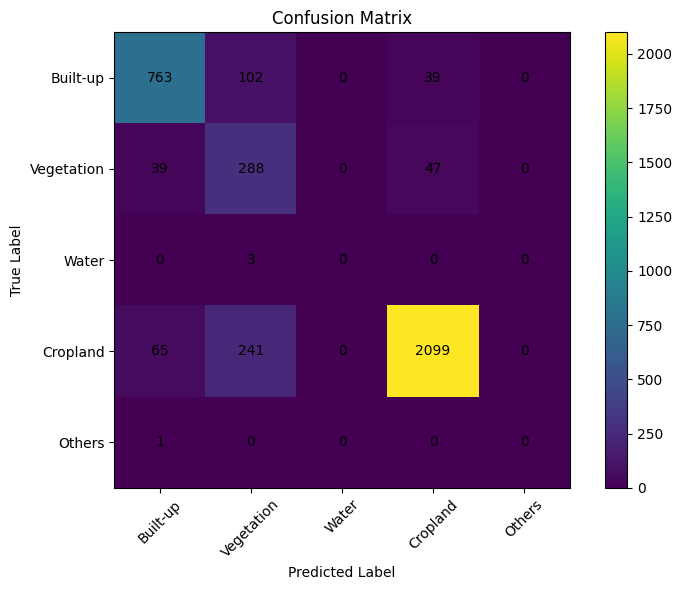

In [ ]:
"""Solution 3: Display a confusion matrix and briefly interpret the results"""

import matplotlib.pyplot as plt

class_names = ["Built-up", "Vegetation", "Water", "Cropland", "Others"]

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], 
                 ha="center", va="center")

plt.tight_layout()
plt.show()

## __*Final Conclusion: The confusion matrix shows that the model performs strongly for dominant classes such as Cropland and Built-up, with high correct classification along the diagonal. Vegetation exhibits moderate confusion, primarily being misclassified as Cropland due to similar texture characteristics in satellite imagery. The minority classes Water and Others are not correctly predicted, likely due to extremely limited training samples (fewer than five instances). Overall, the model demonstrates strong performance for major land-use categories but struggles with severely underrepresented classes. Further we can Exclude the classes with samples < 20 for more better model accuracy..*__

> ## __So it is my conclusion towards the assignment, thank you for reviewing it... - By Rikin Pithadia__
> For more projects and Profile please visit to my [GitHub](https://github.com/rikin-2911) and [LinkedIn](https://www.linkedin.com/in/rikin-pithadia-20b94729b)

